# Experiment Results Analysis

This notebook compares the results from four different experiments:
1. ELS
2. GITTINS_GNN
3. GITTINS_GTStoppingTime
4. GITTINS_GT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

## Load Data

In [2]:
# Load the four experiment files
files = {
    'ELS': 'groundTruthTest_ELS_1_3_1_3_10_0113_233903.STOP.dat',
    'GITTINS_GNN': 'groundTruthTest_GITTINS_GNN_50_3_0113_172714.STOP.dat',
    'GITTINS_GTStoppingTime': 'groundTruthTest_GITTINS_GTStoppingTime_50_9_0115_144535.STOP.dat',
    'GITTINS_GT': 'groundTruthTest_GITTINS_GT_50_9_0115_151823.STOP.dat'
}

data = {}
for name, file in files.items():
    data[name] = pd.read_csv(file)
    print(f"{name}: {len(data[name])} rows loaded")

ELS: 100 rows loaded
GITTINS_GNN: 100 rows loaded
GITTINS_GTStoppingTime: 100 rows loaded
GITTINS_GT: 100 rows loaded


## Display Summary Statistics

In [3]:
# Display summary statistics for each experiment
for name, df in data.items():
    print(f"\n{name}:")
    print(df[['ctot', 'metaCtot', 'gittinsCtot', 'inferenceCtot']].describe())


ELS:
             ctot  metaCtot  gittinsCtot  inferenceCtot
count  100.000000     100.0        100.0          100.0
mean    46.658861       0.0          0.0            0.0
std     15.906071       0.0          0.0            0.0
min     14.335300       0.0          0.0            0.0
25%     35.234200       0.0          0.0            0.0
50%     44.741300       0.0          0.0            0.0
75%     52.852800       0.0          0.0            0.0
max    105.065000       0.0          0.0            0.0

GITTINS_GNN:
             ctot    metaCtot  gittinsCtot  inferenceCtot
count  100.000000  100.000000   100.000000     100.000000
mean     9.005125    5.503022     0.108256       5.394531
std      2.950062    1.591608     0.015044       1.588155
min      3.854670    3.900980     0.088391       3.807840
25%      7.475167    4.802577     0.100037       4.702288
50%      8.713965    5.253040     0.105786       5.120470
75%     10.455525    5.860837     0.115788       5.746232
max     25.3

## Plot Individual Experiment Results

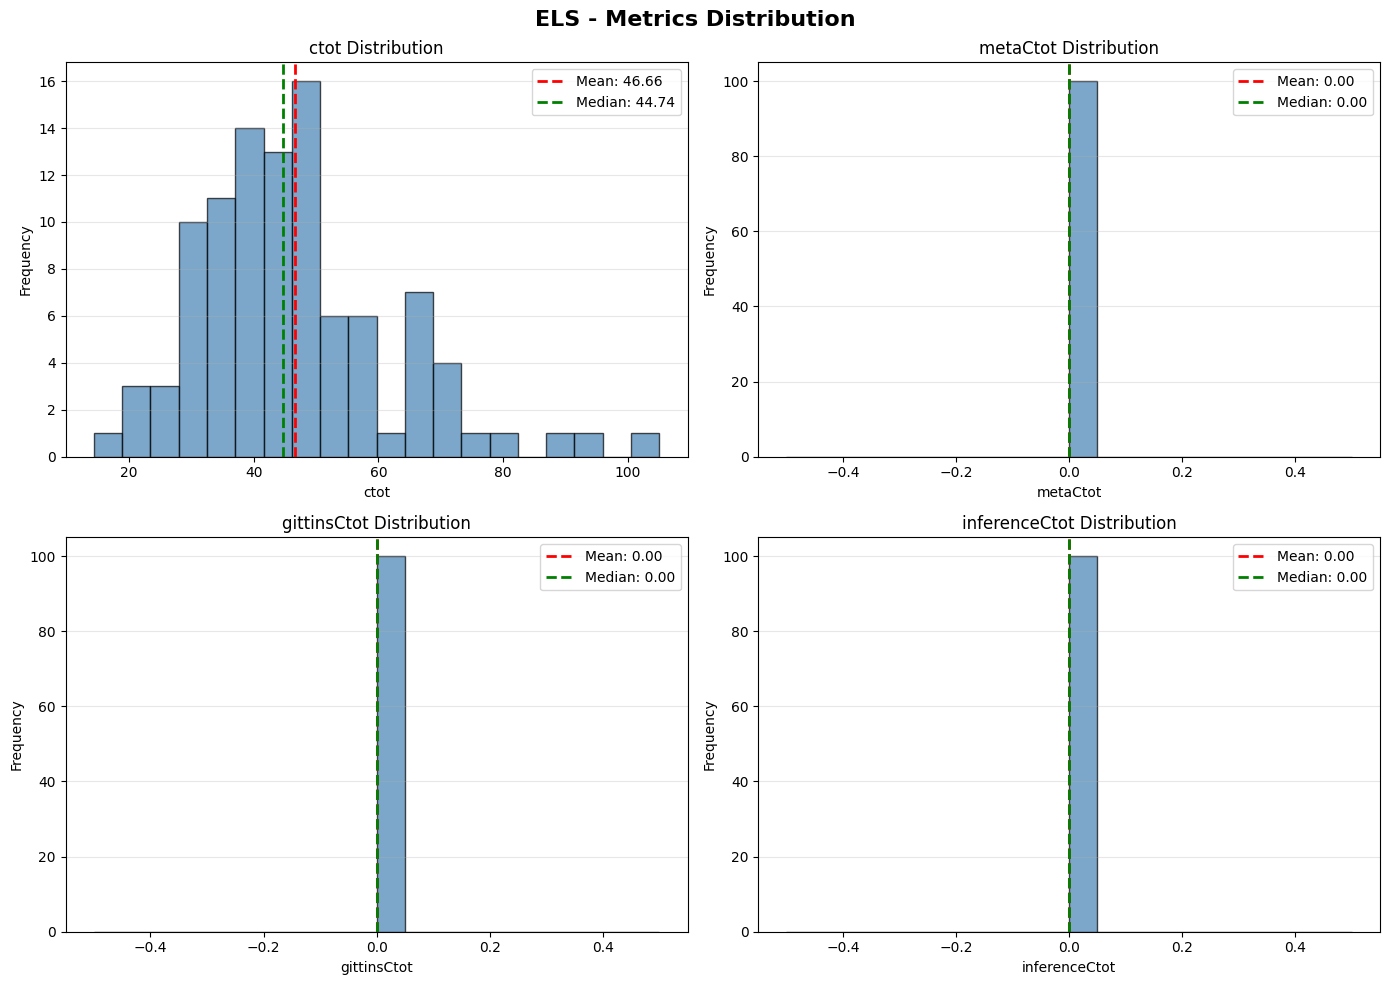

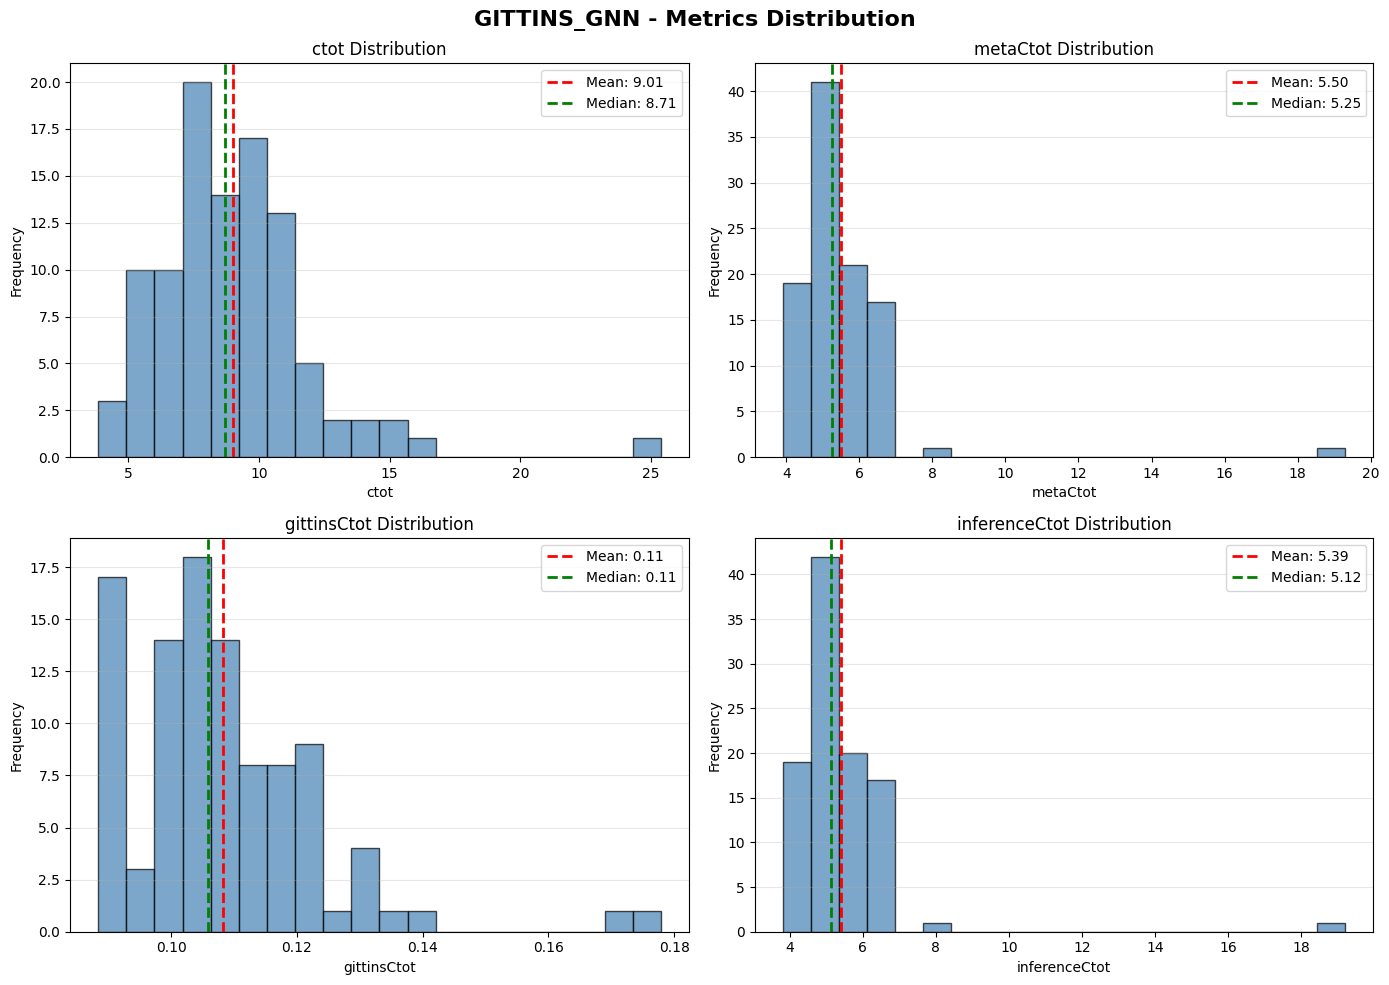

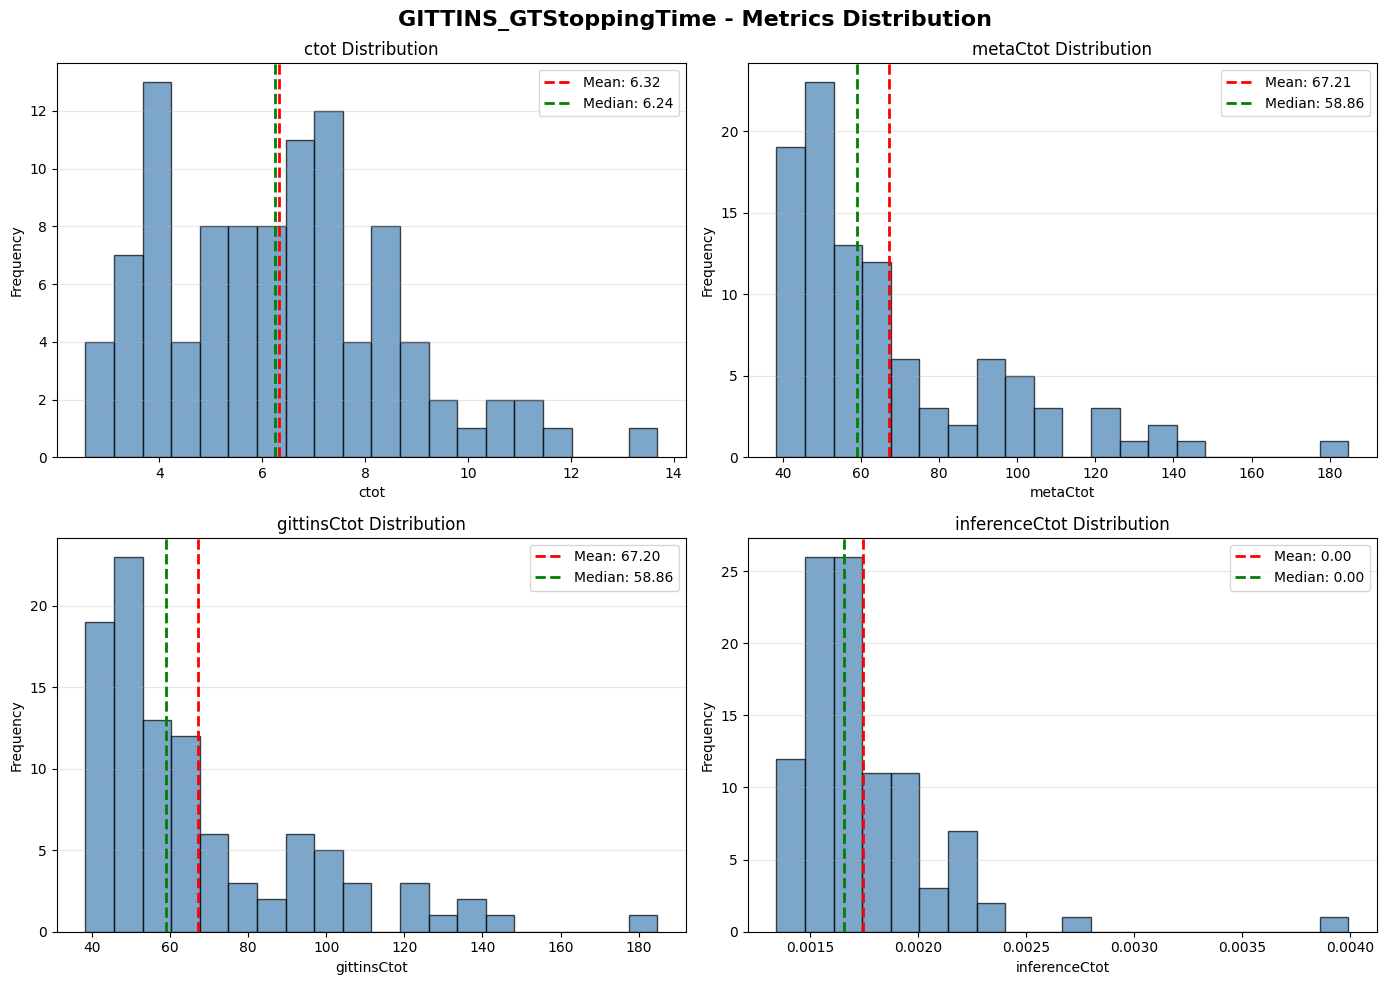

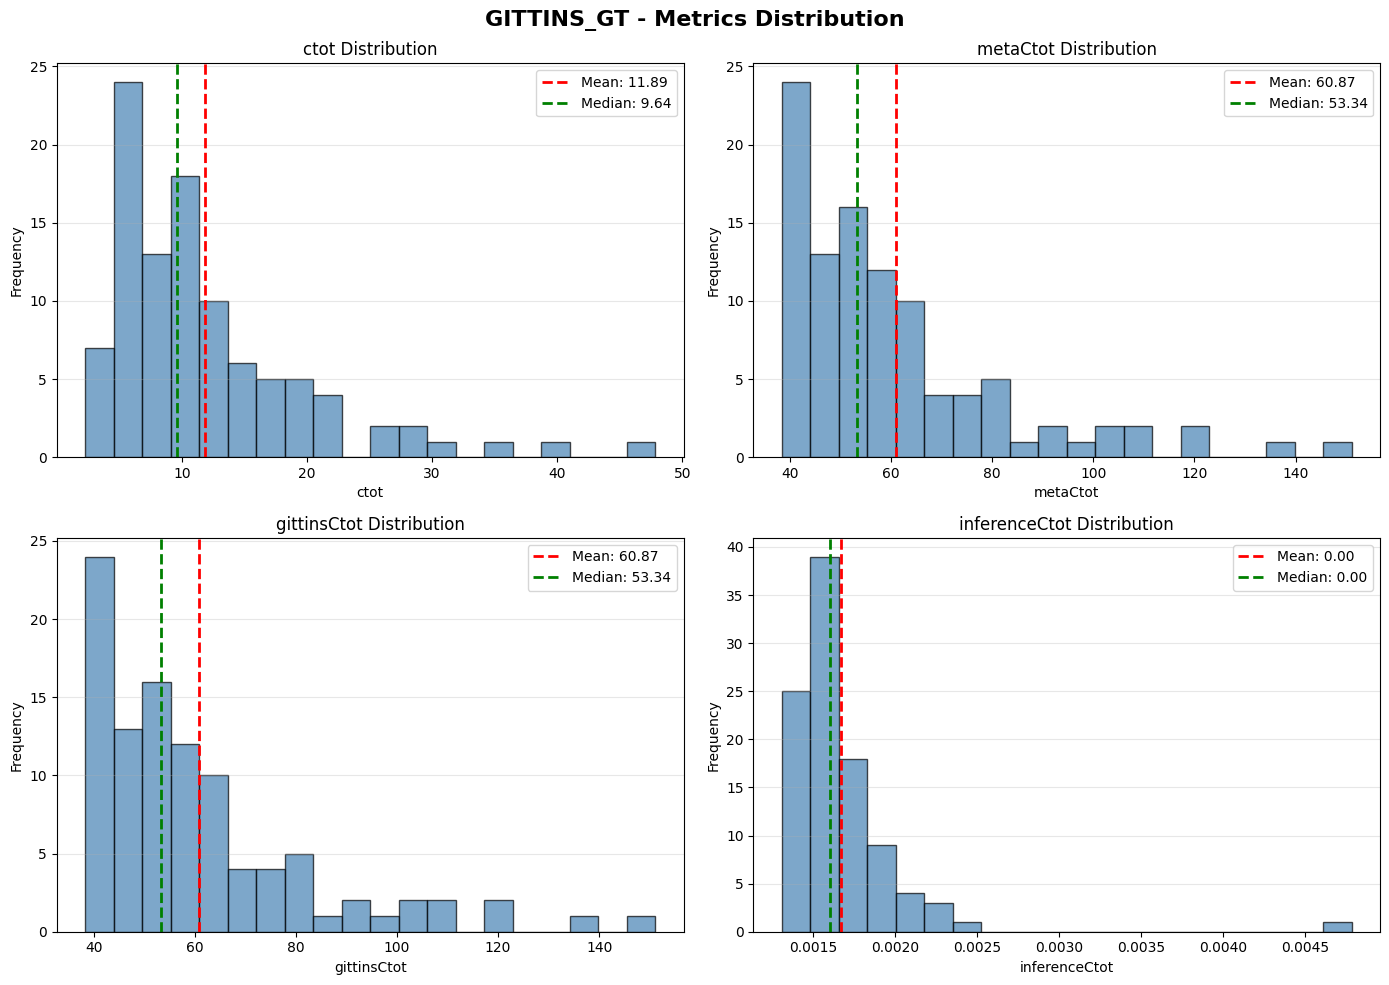

In [5]:
# Create histograms for each experiment
metrics = ['ctot', 'metaCtot', 'gittinsCtot', 'inferenceCtot']

for name, df in data.items():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{name} - Metrics Distribution', fontsize=16, fontweight='bold')
    
    for idx, metric in enumerate(metrics):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]
        
        ax.hist(df[metric], bins=20, alpha=0.7, edgecolor='black', color='steelblue')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{metric} Distribution')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add mean and median lines
        mean_val = df[metric].mean()
        median_val = df[metric].median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


## Compare Experiments - Box Plots

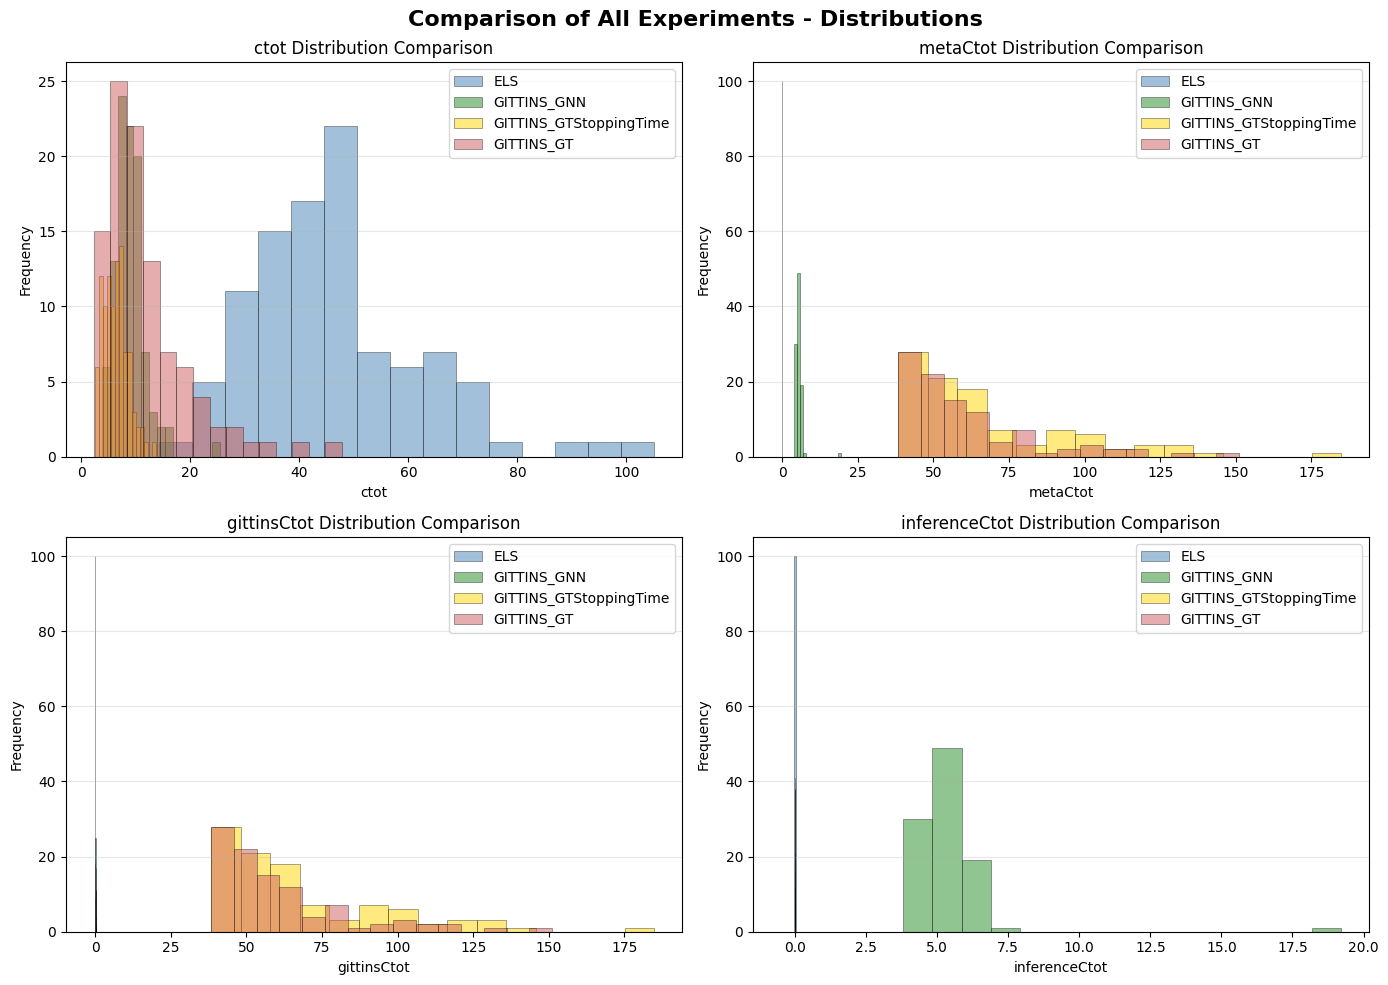

In [6]:
# Compare all experiments using histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparison of All Experiments - Distributions', fontsize=16, fontweight='bold')

colors = ['steelblue', 'forestgreen', 'gold', 'indianred']
experiment_names = list(data.keys())

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot overlaid histograms
    for i, (name, df) in enumerate(data.items()):
        ax.hist(df[metric], bins=15, alpha=0.5, label=name, 
                edgecolor='black', color=colors[i], linewidth=0.5)
    
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{metric} Distribution Comparison')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

plt.tight_layout()
plt.show()


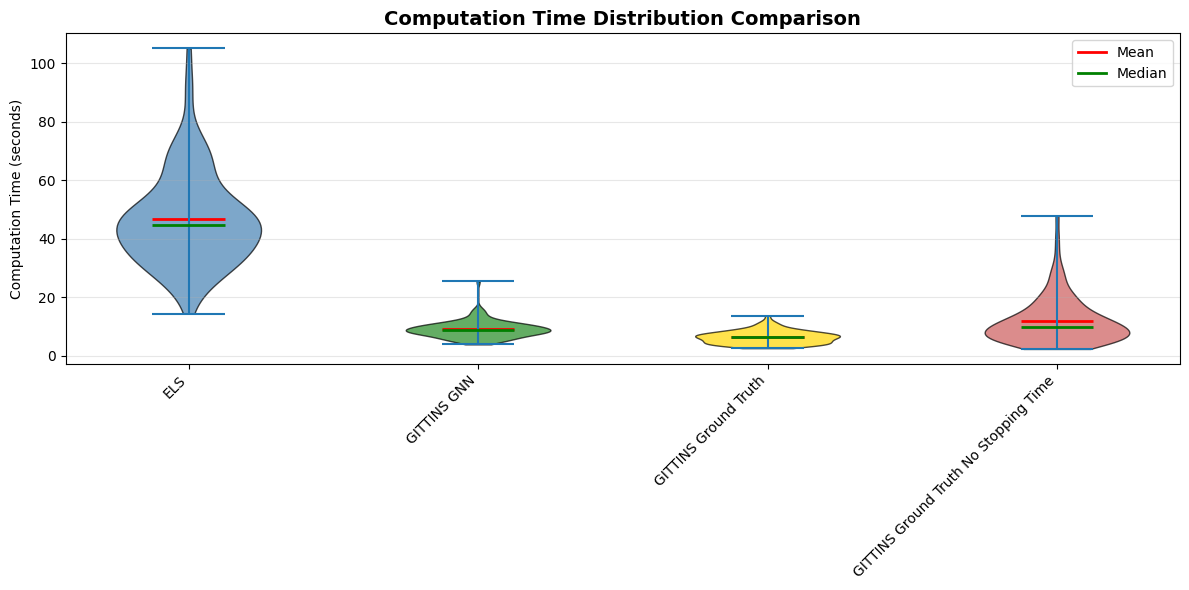


ctot Statistics:
ELS: mean=46.66, median=44.74, std=15.91
GITTINS_GNN: mean=9.01, median=8.71, std=2.95
GITTINS_GTStoppingTime: mean=6.32, median=6.24, std=2.24
GITTINS_GT: mean=11.89, median=9.64, std=8.07


In [16]:
# Create violin plot for ctot comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for violin plot
ctot_data = [df['ctot'] for name, df in data.items()]
labels = ["ELS", "GITTINS GNN", "GITTINS Ground Truth", "GITTINS Ground Truth No Stopping Time"]
colors = ['steelblue', 'forestgreen', 'gold', 'indianred']

# Create violin plot
parts = ax.violinplot(ctot_data, positions=range(len(labels)), 
                      showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

# Customize mean and median lines
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_edgecolor('green')
parts['cmedians'].set_linewidth(2)

# Add labels and title
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Computation Time (seconds)')
ax.set_title('Computation Time Distribution Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add legend for mean and median
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', linewidth=2, label='Mean'),
                   Line2D([0], [0], color='green', linewidth=2, label='Median')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print statistics
print("\nctot Statistics:")
for name, df in data.items():
    print(f"{name}: mean={df['ctot'].mean():.2f}, median={df['ctot'].median():.2f}, std={df['ctot'].std():.2f}")

## Violin Plot - ctot Comparison

In [14]:
from scipy import stats
from scipy.stats import shapiro, levene, kruskal, mannwhitneyu, f_oneway
from itertools import combinations

# First, check normality of ctot distributions
print("=" * 80)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 80)
print("H0: Data is normally distributed (p > 0.05 means normal)")
print("-" * 80)
for name, df in data.items():
    stat, p_value = shapiro(df['ctot'])
    result = "Normal" if p_value > 0.05 else "Not Normal"
    print(f"{name:25s}: W={stat:.4f}, p-value={p_value:.4e} -> {result}")

# Check homogeneity of variances
print("\n" + "=" * 80)
print("HOMOGENEITY OF VARIANCES (Levene's Test)")
print("=" * 80)
print("H0: Variances are equal (p > 0.05 means equal variances)")
print("-" * 80)
ctot_groups = [df['ctot'] for name, df in data.items()]
stat, p_value = levene(*ctot_groups)
variance_result = "Equal variances" if p_value > 0.05 else "Unequal variances"
print(f"Levene statistic={stat:.4f}, p-value={p_value:.4e} -> {variance_result}")

# Overall test: Kruskal-Wallis (non-parametric) since data might not be normal
print("\n" + "=" * 80)
print("OVERALL COMPARISON: KRUSKAL-WALLIS TEST")
print("=" * 80)
print("H0: All groups have the same distribution (p > 0.05 means no difference)")
print("-" * 80)
stat, p_value = kruskal(*ctot_groups)
print(f"Kruskal-Wallis H={stat:.4f}, p-value={p_value:.4e}")
if p_value < 0.05:
    print("Result: Significant difference between algorithms (reject H0)")
else:
    print("Result: No significant difference between algorithms (fail to reject H0)")

# Also run ANOVA for comparison
print("\n" + "=" * 80)
print("OVERALL COMPARISON: ONE-WAY ANOVA (for comparison)")
print("=" * 80)
stat, p_value = f_oneway(*ctot_groups)
print(f"ANOVA F={stat:.4f}, p-value={p_value:.4e}")
if p_value < 0.05:
    print("Result: Significant difference between algorithms (reject H0)")
else:
    print("Result: No significant difference between algorithms (fail to reject H0)")

# Pairwise comparisons using Mann-Whitney U test
print("\n" + "=" * 80)
print("PAIRWISE COMPARISONS: MANN-WHITNEY U TEST")
print("=" * 80)
print("H0: Two groups have the same distribution (p < 0.05 means significant difference)")
print("-" * 80)

experiment_names = list(data.keys())
pairs = list(combinations(experiment_names, 2))
n_comparisons = len(pairs)
bonferroni_alpha = 0.05 / n_comparisons  # Bonferroni correction

print(f"Number of pairwise comparisons: {n_comparisons}")
print(f"Bonferroni-corrected significance level: {bonferroni_alpha:.4f}")
print("-" * 80)

pairwise_results = []
for exp1, exp2 in pairs:
    stat, p_value = mannwhitneyu(data[exp1]['ctot'], data[exp2]['ctot'], alternative='two-sided')
    mean1 = data[exp1]['ctot'].mean()
    mean2 = data[exp2]['ctot'].mean()
    
    # Determine which is better (lower ctot is better)
    better = exp1 if mean1 < mean2 else exp2
    
    significant = "***" if p_value < bonferroni_alpha else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns"))
    
    pairwise_results.append({
        'Comparison': f"{exp1} vs {exp2}",
        'U_statistic': stat,
        'p_value': p_value,
        'mean1': mean1,
        'mean2': mean2,
        'better': better,
        'significant': significant
    })
    
    print(f"{exp1:25s} vs {exp2:25s}: U={stat:8.1f}, p={p_value:.4e} {significant:3s} | Better: {better}")

# Create DataFrame for pairwise results
pairwise_df = pd.DataFrame(pairwise_results)

# Summary
print("\n" + "=" * 80)
print("SUMMARY: MEAN ctot VALUES (Lower is Better)")
print("=" * 80)
summary_data = []
for name, df in data.items():
    summary_data.append({
        'Algorithm': name,
        'Mean': df['ctot'].mean(),
        'Std': df['ctot'].std(),
        'Median': df['ctot'].median(),
        'Min': df['ctot'].min(),
        'Max': df['ctot'].max()
    })

summary_df = pd.DataFrame(summary_data).sort_values('Mean')
print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("* ns: not significant")
print("* *: p < 0.05 (significant)")
print("** **: p < 0.01 (highly significant)")
print("* ***: p < Bonferroni-corrected alpha (significant after multiple comparison correction)")
print(f"\nBest performing algorithm (lowest mean ctot): {summary_df.iloc[0]['Algorithm']}")

NORMALITY TESTS (Shapiro-Wilk)
H0: Data is normally distributed (p > 0.05 means normal)
--------------------------------------------------------------------------------
ELS                      : W=0.9440, p-value=3.4012e-04 -> Not Normal
GITTINS_GNN              : W=0.8775, p-value=1.4266e-07 -> Not Normal
GITTINS_GTStoppingTime   : W=0.9687, p-value=1.7511e-02 -> Not Normal
GITTINS_GT               : W=0.8246, p-value=1.5177e-09 -> Not Normal

HOMOGENEITY OF VARIANCES (Levene's Test)
H0: Variances are equal (p > 0.05 means equal variances)
--------------------------------------------------------------------------------
Levene statistic=52.4666, p-value=1.4230e-28 -> Unequal variances

OVERALL COMPARISON: KRUSKAL-WALLIS TEST
H0: All groups have the same distribution (p > 0.05 means no difference)
--------------------------------------------------------------------------------
Kruskal-Wallis H=252.8633, p-value=1.5723e-54
Result: Significant difference between algorithms (reject H0)

O

## Statistical Tests - ctot Performance Comparison

In [17]:
# Perform specific one-sided Wilcoxon rank-sum tests (Mann-Whitney U)
# Testing if one algorithm has significantly lower ctot than another (one-sided)

print("=" * 80)
print("ONE-SIDED WILCOXON RANK-SUM TESTS (Mann-Whitney U)")
print("=" * 80)
print("H0: The two groups have equal distributions")
print("H1: First group has lower values than second group (one-sided)")
print("Lower ctot is better, so we test if the first algorithm < second algorithm")
print("=" * 80)

# Test 1: GITTINS_GNN vs ELS (Is GITTINS_GNN better than ELS?)
print("\n1. Test if GITTINS_GNN is better than ELS")
print("-" * 80)
gnn_data = data['GITTINS_GNN']['ctot']
els_data = data['ELS']['ctot']

stat, p_value = mannwhitneyu(gnn_data, els_data, alternative='less')
gnn_mean = gnn_data.mean()
els_mean = els_data.mean()
mean_diff = els_mean - gnn_mean
percent_improvement = (mean_diff / els_mean) * 100

print(f"GITTINS_GNN mean: {gnn_mean:.4f}")
print(f"ELS mean:         {els_mean:.4f}")
print(f"Difference:       {mean_diff:.4f} ({percent_improvement:.2f}% improvement)")
print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"One-sided p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"Result: ✓ GITTINS_GNN is SIGNIFICANTLY better than ELS (p < 0.05)")
else:
    print(f"Result: ✗ GITTINS_GNN is NOT significantly better than ELS (p >= 0.05)")

# Test 2: GITTINS_GTStoppingTime vs GITTINS_GT
print("\n" + "=" * 80)
print("2. Test if GITTINS_GTStoppingTime is better than GITTINS_GT")
print("-" * 80)
gt_stopping_data = data['GITTINS_GTStoppingTime']['ctot']
gt_data = data['GITTINS_GT']['ctot']

stat, p_value = mannwhitneyu(gt_stopping_data, gt_data, alternative='less')
gt_stopping_mean = gt_stopping_data.mean()
gt_mean = gt_data.mean()
mean_diff = gt_mean - gt_stopping_mean
percent_improvement = (mean_diff / gt_mean) * 100

print(f"GITTINS_GTStoppingTime mean: {gt_stopping_mean:.4f}")
print(f"GITTINS_GT mean:             {gt_mean:.4f}")
print(f"Difference:                  {mean_diff:.4f} ({percent_improvement:.2f}% improvement)")
print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"One-sided p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"Result: ✓ GITTINS_GTStoppingTime is SIGNIFICANTLY better than GITTINS_GT (p < 0.05)")
else:
    print(f"Result: ✗ GITTINS_GTStoppingTime is NOT significantly better than GITTINS_GT (p >= 0.05)")

# Test 3: GITTINS_GTStoppingTime vs GITTINS_GNN
print("\n" + "=" * 80)
print("3. Test if GITTINS_GTStoppingTime is better than GITTINS_GNN")
print("-" * 80)

stat, p_value = mannwhitneyu(gt_stopping_data, gnn_data, alternative='less')
mean_diff = gnn_mean - gt_stopping_mean
percent_improvement = (mean_diff / gnn_mean) * 100

print(f"GITTINS_GTStoppingTime mean: {gt_stopping_mean:.4f}")
print(f"GITTINS_GNN mean:            {gnn_mean:.4f}")
print(f"Difference:                  {mean_diff:.4f} ({percent_improvement:.2f}% improvement)")
print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"One-sided p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"Result: ✓ GITTINS_GTStoppingTime is SIGNIFICANTLY better than GITTINS_GNN (p < 0.05)")
else:
    print(f"Result: ✗ GITTINS_GTStoppingTime is NOT significantly better than GITTINS_GNN (p >= 0.05)")

# Summary
print("\n" + "=" * 80)
print("SUMMARY OF ONE-SIDED TESTS")
print("=" * 80)
print("All tests use significance level α = 0.05")
print("Wilcoxon rank-sum test (Mann-Whitney U) with one-sided alternative")
print("Testing if the first algorithm has significantly lower ctot (is better)")
print("=" * 80)

ONE-SIDED WILCOXON RANK-SUM TESTS (Mann-Whitney U)
H0: The two groups have equal distributions
H1: First group has lower values than second group (one-sided)
Lower ctot is better, so we test if the first algorithm < second algorithm

1. Test if GITTINS_GNN is better than ELS
--------------------------------------------------------------------------------
GITTINS_GNN mean: 9.0051
ELS mean:         46.6589
Difference:       37.6537 (80.70% improvement)

Mann-Whitney U statistic: 9.00
One-sided p-value: 0.000000
Result: ✓ GITTINS_GNN is SIGNIFICANTLY better than ELS (p < 0.05)

2. Test if GITTINS_GTStoppingTime is better than GITTINS_GT
--------------------------------------------------------------------------------
GITTINS_GTStoppingTime mean: 6.3175
GITTINS_GT mean:             11.8867
Difference:                  5.5692 (46.85% improvement)

Mann-Whitney U statistic: 2453.00
One-sided p-value: 0.000000
Result: ✓ GITTINS_GTStoppingTime is SIGNIFICANTLY better than GITTINS_GT (p < 0.05)


## Specific One-Sided Wilcoxon Tests

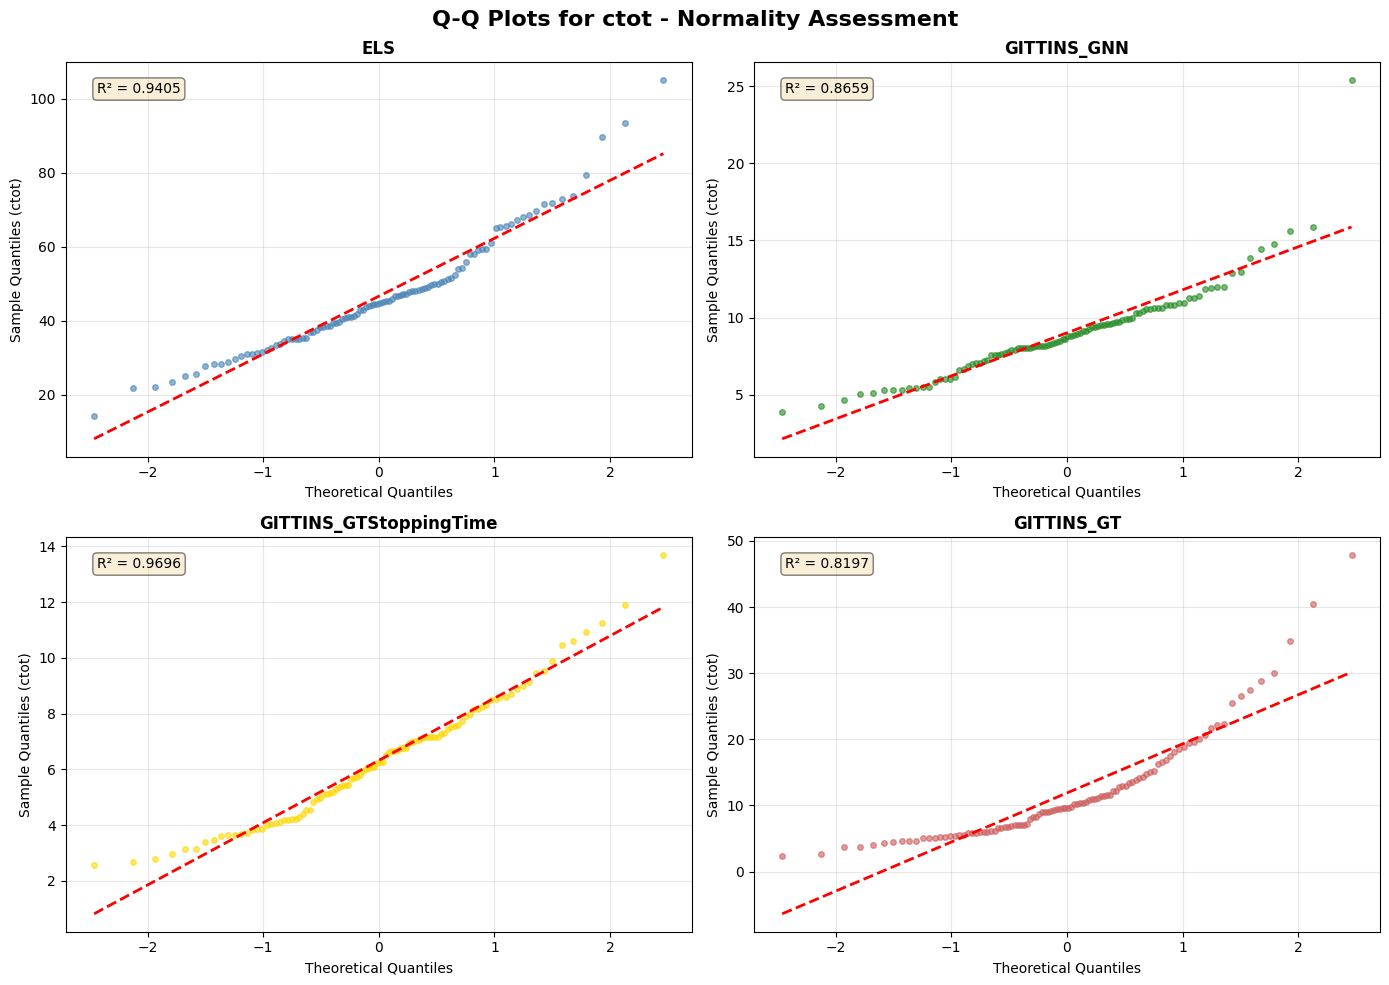


Interpretation:
--------------------------------------------------------------------------------
If the data points closely follow the red diagonal line, the data is normally distributed.
Deviations from the line indicate departure from normality.
R² values closer to 1.0 indicate better fit to normal distribution.


In [15]:
# Create Q-Q plots for ctot to assess normality
from scipy.stats import probplot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q-Q Plots for ctot - Normality Assessment', fontsize=16, fontweight='bold')

colors = ['steelblue', 'forestgreen', 'gold', 'indianred']
experiment_names = list(data.keys())

for idx, (name, df) in enumerate(data.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Create Q-Q plot
    stats_result = probplot(df['ctot'], dist="norm", plot=ax)
    
    # Customize the plot
    ax.get_lines()[0].set_markerfacecolor(colors[idx])
    ax.get_lines()[0].set_markeredgecolor(colors[idx])
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[0].set_alpha(0.6)
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linewidth(2)
    ax.get_lines()[1].set_linestyle('--')
    
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles (ctot)')
    ax.grid(True, alpha=0.3)
    
    # Calculate R² for goodness of fit to normal distribution
    r_squared = stats_result[1][2] ** 2
    ax.text(0.05, 0.95, f'R² = {r_squared:.4f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("-" * 80)
print("If the data points closely follow the red diagonal line, the data is normally distributed.")
print("Deviations from the line indicate departure from normality.")
print("R² values closer to 1.0 indicate better fit to normal distribution.")

## Q-Q Plots - Normality Check for ctot

## Compare Experiments - Mean Values

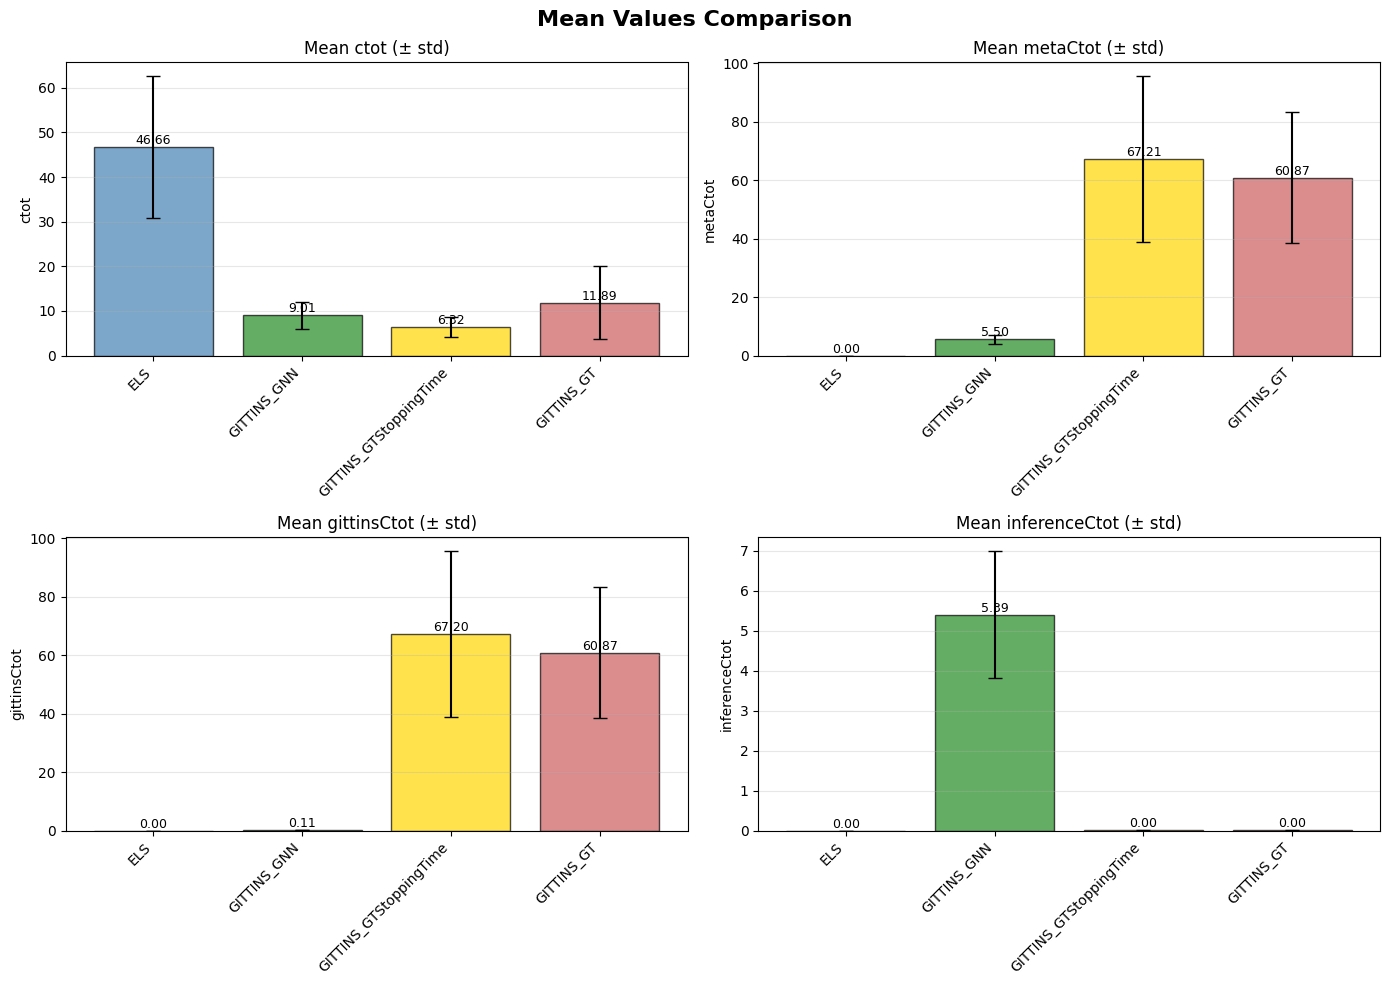

In [10]:
# Bar plot comparing mean values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mean Values Comparison', fontsize=16, fontweight='bold')

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    means = [df[metric].mean() for name, df in data.items()]
    stds = [df[metric].std() for name, df in data.items()]
    labels = list(data.keys())
    
    colors = ['steelblue', 'forestgreen', 'gold', 'indianred']
    bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
    
    ax.set_ylabel(metric)
    ax.set_title(f'Mean {metric} (± std)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()